In [1]:
import numpy as np 
import pandas as pd 
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
labels = os.listdir(r"C:\Users\Mohan\Documents\driver_drowsiness\train")

In [3]:
labels

['Closed', 'no_yawn', 'Open', 'yawn']

In [4]:
#for yawn and not_yawn . taking only face
def face_for_yawn(direc=r"C:\Users\Mohan\Documents\driver_drowsiness\train", face_cas_path=r"C:\Users\Mohan\Documents\driver_drowsiness\haarcascade_frontalface_default.xml"):
    yaw_no = []
    IMG_SIZE = 145
    categories = ["yawn", "no_yawn"]
    for category in categories:
        path_link = os.path.join(direc, category)
        class_num1 = categories.index(category)
        print(class_num1)
        for image in os.listdir(path_link):
            image_array = cv2.imread(os.path.join(path_link, image), cv2.IMREAD_COLOR)
            face_cascade = cv2.CascadeClassifier(face_cas_path)
            faces = face_cascade.detectMultiScale(image_array, 1.3, 5)
            for (x, y, w, h) in faces:
                img = cv2.rectangle(image_array, (x, y), (x+w, y+h), (0, 255, 0), 2)
                roi_color = img[y:y+h, x:x+w]
                resized_array = cv2.resize(roi_color, (IMG_SIZE, IMG_SIZE))
                yaw_no.append([resized_array, class_num1])
    return yaw_no


yawn_no_yawn = face_for_yawn()

0
1


In [5]:
#for closed and open eye
def get_data(dir_path=r"C:\Users\Mohan\Documents\driver_drowsiness\train", face_cas=r"C:\Users\Mohan\Documents\driver_drowsiness\haarcascade_frontalface_default.xml", eye_cas=r"C:\Users\Mohan\Documents\driver_drowsiness\haarcascade_eye.xml"):
    labels = ['Closed', 'Open']
    IMG_SIZE = 145
    data = []
    for label in labels:
        path = os.path.join(dir_path, label)
        class_num = labels.index(label)
        class_num +=2
        print(class_num)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                data.append([resized_array, class_num])
            except Exception as e:
                print(e)
    return data

In [6]:
data_train = get_data()

2
3


In [7]:
#extend data and convert array
def append_data():
    yaw_no = face_for_yawn()
    data = get_data()
    yaw_no.extend(data)

    X = []
    y = []
    for item in yaw_no:
        if len(item) != 2:
            print("Bad item found:", item)
            continue
        features, label = item
        X.append(features)
        y.append(label)

    return np.array(X), np.array(y)


In [8]:
#new variable to store
X, y = append_data()


0
1
2
3


In [9]:
#reshape the array
X = np.array(X)
X = X.reshape(-1, 145, 145, 3)

In [10]:
#labelBinarizer
from sklearn.preprocessing import LabelBinarizer
label_bin = LabelBinarizer()
y = label_bin.fit_transform(y)

In [11]:
#label array
y = np.array(y)

In [12]:
#train test
from sklearn.model_selection import train_test_split
seed = 42
test_size = 0.30
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=test_size)

In [13]:
len(X_test)

578

In [14]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

In [15]:
import sys
print(sys.executable)


C:\Users\Mohan\anaconda3\envs\tfenv\python.exe


In [16]:
#data augmentation
train_generator = ImageDataGenerator(rescale=1/255, zoom_range=0.2, horizontal_flip=True, rotation_range=30)
test_generator = ImageDataGenerator(rescale=1/255)

train_generator = train_generator.flow(np.array(X_train), y_train, shuffle=False)
test_generator = test_generator.flow(np.array(X_test), y_test, shuffle=False)

In [17]:
#CNN model
model = Sequential()

model.add(Conv2D(256, (3, 3), activation="relu", input_shape=X_train.shape[1:]))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())
model.add(Dropout(0.5))

model.add(Dense(64, activation="relu"))
model.add(Dense(4, activation="softmax"))

model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

model.summary()

C:\Users\Mohan\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 143, 143, 256)       │           7,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 71, 71, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 69, 69, 128)         │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 34, 34, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1568)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1568)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         100,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 495,140 (1.89 MB)

 Trainable params: 495,140 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(train_generator, epochs=40, validation_data=test_generator, shuffle=True, validation_steps=len(test_generator))

C:\Users\Mohan\anaconda3\envs\tfenv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.3866 - loss: 1.3205 - val_accuracy: 0.6817 - val_loss: 0.8733
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.7373 - loss: 0.6352 - val_accuracy: 0.8651 - val_loss: 0.3617
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.8008 - loss: 0.4785 - val_accuracy: 0.8875 - val_loss: 0.2852
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8662 - loss: 0.3487 - val_accuracy: 0.9066 - val_loss: 0.2708
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8828 - loss: 0.2938 - val_accuracy: 0.9083 - val_loss: 0.2758
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8817 - loss: 0.2687 - val_accuracy: 0.9118 - val_loss: 0.2452
Epoch 7/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.8766 - loss: 0.2629 - val_accuracy: 0.8962 - val_loss: 0.2524
Epoch 8/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.8901 - loss: 0.3068 - val_accuracy: 0.9187 - v

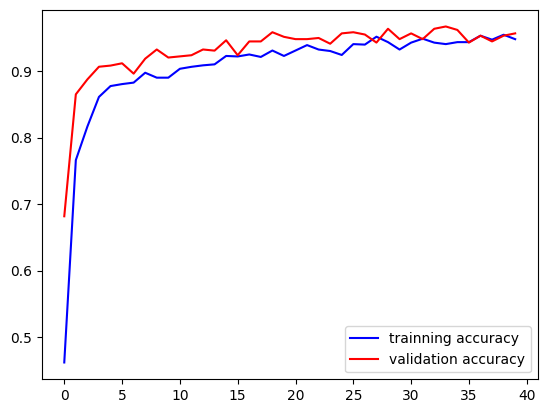

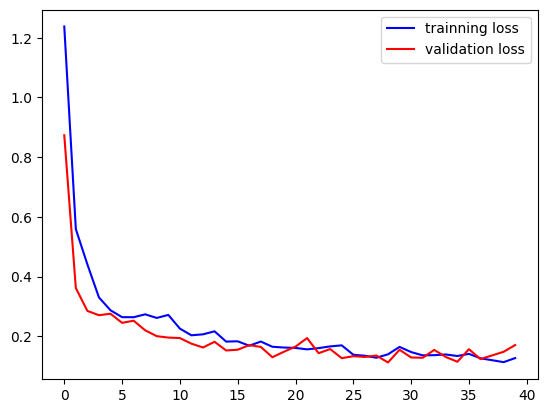

In [19]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, "b", label="trainning accuracy")
plt.plot(epochs, val_accuracy, "r", label="validation accuracy")
plt.legend()
plt.show()

plt.plot(epochs, loss, "b", label="trainning loss")
plt.plot(epochs, val_loss, "r", label="validation loss")
plt.legend()
plt.show()

In [20]:
model.save("drowiness_new6.h5")

In [21]:
model.save("drowiness_new6.keras")


In [22]:
import numpy as np

# Predict probabilities
y_prob = model.predict(X_test)

# Get class with highest probability
prediction = np.argmax(y_prob, axis=1)


19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 573ms/step


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Get true labels
y_true = np.argmax(y_test, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_true, prediction)
precision = precision_score(y_true, prediction, average='macro')  # use 'binary' if only 2 classes
recall = recall_score(y_true, prediction, average='macro')
f1 = f1_score(y_true, prediction, average='macro')

# Display as table
metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

print(metrics_table)


      Metric     Score
0   Accuracy  0.953287
1  Precision  0.939037
2     Recall  0.926360
3   F1 Score  0.931049


In [24]:
#classification report
labels_new = ["yawn", "no_yawn", "Closed", "Open"]

In [25]:
from sklearn.metrics import classification_report
print(classification_report(np.argmax(y_test, axis=1), prediction, target_names=labels_new))

              precision    recall  f1-score   support

        yawn       0.94      0.81      0.87        63
     no_yawn       0.88      0.95      0.91        74
      Closed       0.96      0.97      0.97       215
        Open       0.97      0.98      0.98       226

    accuracy                           0.95       578
   macro avg       0.94      0.93      0.93       578
weighted avg       0.95      0.95      0.95       578



In [26]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Convert model predictions to class labels
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

# If y_test is one-hot encoded, convert it to class labels
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Print it
print("Confusion Matrix:")
print(cm)


19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 471ms/step
Confusion Matrix:
[[ 51  10   2   0]
 [  2  70   1   1]
 [  1   0 209   5]
 [  0   0   5 221]]


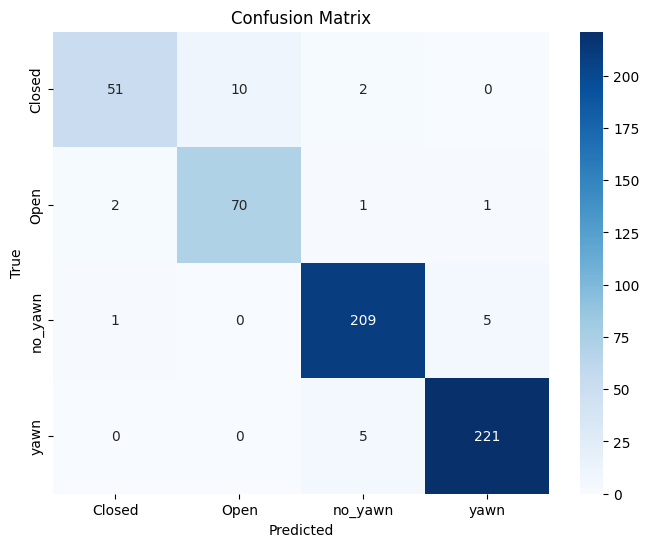

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: Class names
class_names = ['Closed', 'Open', 'no_yawn', 'yawn']  # adjust as per your actual labels

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [28]:
#predicting function
labels_new = ["yawn", "no_yawn", "Closed", "Open"]
IMG_SIZE = 145
def prepare(filepath, face_cas="../input/prediction-images/haarcascade_frontalface_default.xml"):
    img_array = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img_array = img_array / 255
    resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
    return resized_array.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

model = tf.keras.models.load_model("./drowiness_new6.h5")

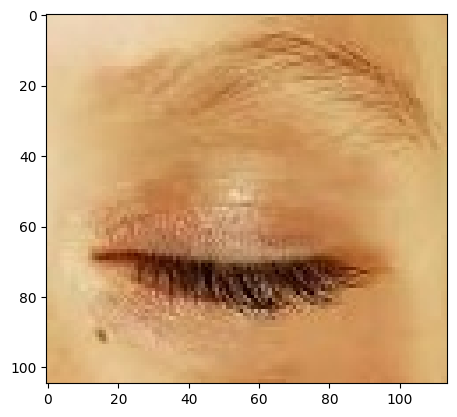

In [29]:
#testing the image is working or not in dataset
plt.imshow(plt.imread("C:/Users/Mohan/Documents/driver_drowsiness/train/Closed/_73.jpg"))

In [30]:
#image array
a = plt.imread("C:/Users/Mohan/Documents/driver_drowsiness/train/yawn/15.jpg")

In [31]:
a.shape #image shape

(480, 640, 3)

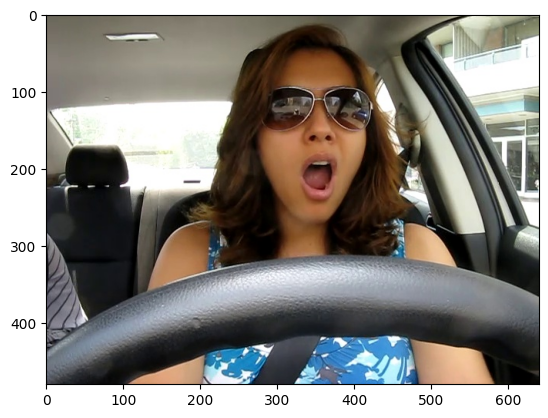

In [32]:
plt.imshow(plt.imread("C:/Users/Mohan/Documents/driver_drowsiness/train/yawn/73.jpg"))

# Prediction 
## 0-yawn, 1-no_yawn, 2-Closed, 3-Open

In [33]:
# prepare("../input/drowsiness-dataset/train/no_yawn/1068.jpg")
prediction = model.predict([prepare("C:/Users/Mohan/Documents/driver_drowsiness/train/no_yawn/1067.jpg")])
np.argmax(prediction)

C:\Users\Mohan\anaconda3\envs\tfenv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(1, 145, 145, 3))',)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


0

In [34]:
prediction = model.predict([prepare("C:/Users/Mohan/Documents/driver_drowsiness/train/Closed/_101.jpg")])
np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


2

In [35]:
prediction = model.predict([prepare("C:/Users/Mohan/Documents/driver_drowsiness/train/Open/_104.jpg")])
np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


3

In [36]:
prediction = model.predict([prepare("C:/Users/Mohan/Documents/driver_drowsiness/train/yawn/113.jpg")])
np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


0